In [2]:
# This is what I'm gonna need for the wavelet transform
import sys
sys.path.append("/home/r/Robert.Reichert/juwavelet")
import juwavelet.transform as transform
from juwavelet import utils

# This is for the data preprocessing and the segmentation
sys.path.append('../scripts')
import utils_2d as two
import plot_tools as pt
import utils_AWE as awe

import xarray as xr
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import copy

plt.style.use("../latex_default_AMT.mplstyle")

/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
data_path = '../data/awe_l3c_q20_2024123T0557_02514_v01.nc'
ds = xr.open_dataset(data_path)

In [4]:
orig = ds["Radiance"].isel(time=0,x_along_track=slice(5100,5800),y_cross_track=slice(85,353))
orig_copy = orig.copy()
BI_high, BI_low = two.BG_removal(orig_copy.values,max_order=1)
dx, dy = 2000, 2000
nx, ny = orig['x_along_track'].size, orig['y_cross_track'].size
y = np.linspace(0,(ny-1)*dy,ny)*1e-3
x = np.linspace(0,(nx-1)*dx,nx)*1e-3
print('Domain size:', nx, ny)

nmask  = orig.shape
ntap   = int(0.1*np.min(nmask))
signal = utils.smooth_edges(BI_high, ntap, window='tukey')

Domain size: 700 268


In [5]:
s0 = 4 #smallest scale that we wanna resolve
s1 = 0.5 * min([nx,ny]) #largest scale we wanna resolve (since the first Fourier component is part of the background (BI_low) the largest scale fits twice in the domain)
dj = 1 / 8 # apäter wieder dj=1/8
js = int(1/dj*np.log2(s1/s0))
jt = 21
print('Decomposition shape will be: ', js, jt, nx, ny)

cwt_result = transform.decompose2d(signal,dx,dy,s0*min([dx,dy]),dj,js,jt,aspect=1,nxpad=None,nypad=None,opts={'param': 2*np.pi},mode="scaled",dtype=np.complex128)

print(f"The data resolution is {dx*1e-3:.0f} km and the smallest wavelength you analyze is {cwt_result['period'][0]*1e-3:.0f} km.")
print(f"The data domain is at least {min([nx,ny])*dx*1e-3:.0f} km and the largest wavelength you analyze is {cwt_result['period'][-1]*1e-3:.0f} km.")

Decomposition shape will be:  40 21 700 268


/home/r/Robert.Reichert/juwavelet/juwavelet/transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))


The data resolution is 2 km and the smallest wavelength you analyze is 8 km.
The data domain is at least 536 km and the largest wavelength you analyze is 235 km.


/home/r/Robert.Reichert/juwavelet/juwavelet/transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


In [6]:
# Denoising
noise_floor = 0.15 #units of BI
wavy_stuff, denoised_cwt = two.denoise_2d(cwt_result,white_noise_level=noise_floor,sMAD_threshold=3)

In [9]:
WAS        = np.abs(denoised_cwt['decomposition'])
seg_v1     = two.wavefield_segmentation_2d(WAS,noise_floor,connectivity_order=2)
print('Identified', np.max(seg_v1), 'initial wave packets!')
WP_labels  = np.arange(1,np.max(seg_v1)+1)
cluster_labels = two.find_clusters_in_freq_theta(denoised_cwt, seg_v1, eps=0.1)
cluster_map    = two.build_cluster_map_with_noise(WP_labels,cluster_labels)
seg_v2         = two.relabel_by_xy_overlap(seg_v1, cluster_map)
print('Reduced the number of wave packets to', np.max(seg_v2))
seg_v3         = two.variance_filter(denoised_cwt, seg_v2, var_threshold=0.99)
print('Final number of wave packets:', np.max(seg_v3))

Identified 112 initial wave packets!
Reduced the number of wave packets to 17
Final number of wave packets: 6


In [10]:
recon_WP1, amp_WP1, k_along_WP1, k_across_WP1 = two.recon_WPoi_2d(denoised_cwt,seg_v3,[1])

100%|██████████| 187600/187600 [00:06<00:00, 30454.89it/s]


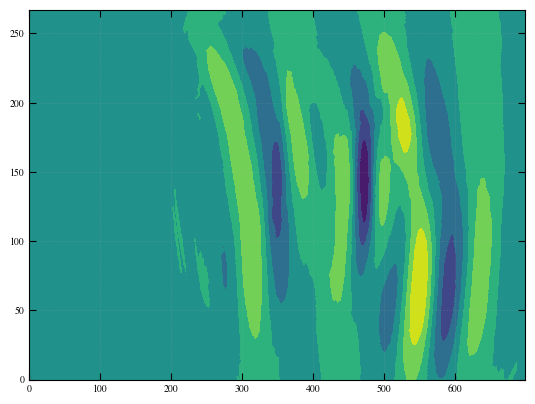

In [11]:
plt.contourf(recon_WP1)

In [14]:
np.round(denoised_cwt['period']*1e-3)

array([  8.,   9.,  10.,  10.,  11.,  12.,  13.,  15.,  16.,  17.,  19.,
        21.,  23.,  25.,  27.,  29.,  32.,  35.,  38.,  41.,  45.,  49.,
        54.,  59.,  64.,  70.,  76.,  83.,  91.,  99., 108., 117., 128.,
       140., 152., 166., 181., 197., 215., 235.])